In [10]:
# ==== Core Libraries ====
import os
import random
from collections import Counter
from datetime import datetime

# ==== Data Processing ====
import numpy as np
import pandas as pd
from scipy import stats

# ==== PyTorch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler

# ==== Machine Learning Utils ====
#from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# ==== Visualization ====
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
class Discriminator(nn.Module):
    def __init__(self, input_channel, features_d, num_classes, num_aps, input_width):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes
        self.num_aps = num_aps
        self.input_width = input_width
        self.input_channel = input_channel

        if self.num_aps == 11:
            last_kernal_size = 12
            last_stride = 5
            last_padding = 4

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(self.input_channel, features_d, kernel_size=4, stride=1, padding=4),
            nn.LeakyReLU(0.2),
            self._block(features_d, features_d * 2, 10, 1, 4),
            self._block(features_d * 2, features_d * 4, 10, 1, 4),
            self._block(features_d * 4, features_d * 8, 10, 2, 4),
        )

        self.classifier = nn.Conv2d(features_d * 8, num_classes + 1,
                                    kernel_size=last_kernal_size,
                                    stride=last_stride,
                                    padding=last_padding)

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x, labels):
        features = self.feature_extractor(x)  # shape: [B, F, H, W]
        logits = self.classifier(features)    # shape: [B, K+1, 1, 1]
        return logits.view(x.size(0), -1)     # shape: [B, K+1]


class Generator(nn.Module):
  def __init__(self,
                channels_noise,
                input_channel,
                features_g,
                num_classes,
                num_aps,
                input_width,
                embed_size):
    super(Generator, self).__init__()
    self.num_aps = num_aps
    self.input_channel = input_channel
    self.input_width = input_width
    self.embed_size = embed_size
    self.net = nn.Sequential(
      self._block(channels_noise + embed_size, features_g * 8, 10, 1, 4),  # img: 12x21
      self._block(features_g * 8, features_g * 4, 10, 1, 4),  # img: 13x22
      self._block(features_g * 4, features_g * 2, 10, 1, 4),  # img: 14x23
      self._block(features_g * 2, features_g, 10, 1, 4),  # img: 15x24
      nn.ConvTranspose2d(features_g, input_channel, kernel_size=9, stride=1, padding=6),
      nn.Tanh(),
      #nn.ReLU()
    )
    self.embed = nn.Embedding(num_classes, embed_size * num_aps * input_width)


  def _block(self, in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
      nn.ConvTranspose2d(
          in_channels, out_channels, kernel_size, stride, padding, bias=False,
      ),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(),
    )

  def forward(self, x, labels):
    # latent vector z: N x noise_dim x 1 x 1
    embedding = self.embed(labels).view(labels.shape[0], self.embed_size, self.num_aps, self.input_width)
    x = torch.cat([x, embedding], dim=1)  # N x C x img_size(H) x img_size(W)
    return self.net(x)

In [12]:
def get_gradient_norm(model):
  total_norm = 0.0
  for p in model.parameters():
    if p.grad is not None:
      param_norm = p.grad.data.norm(2)
      total_norm += param_norm.item() ** 2
  return total_norm ** 0.5

def freeze_discriminator(disc, num_classes, unfreeze_net_last=False):

  # === Freeze everything by default ===
  for param in disc.parameters():
    param.requires_grad = False

  # === Reinitialize the classifier layer ===
  with torch.no_grad():
    old_classifier = disc.classifier
    disc.classifier = nn.Conv2d(
        in_channels=old_classifier.in_channels,
        out_channels=num_classes + 1,     # NUM_CLASSES + 1 fake
        kernel_size=old_classifier.kernel_size,
        stride=old_classifier.stride,
        padding=old_classifier.padding,
        bias=True
    )

  # === Unfreeze classifier ===
  for param in disc.classifier.parameters():
    param.requires_grad = True

  # === Reset BatchNorm running stats ===
  for m in disc.modules():
    if isinstance(m, nn.BatchNorm2d):
      m.running_mean.zero_()
      m.running_var.fill_(1)

def freeze_generator(gen):
  for param in gen.parameters():
    param.requires_grad = False

In [13]:
def load_pretrained_models(checkpoint_path):

  checkpoint = torch.load(checkpoint_path, map_location="cpu")

  gen = Generator(Z_DIM, CHANNELS_RSSI, FEATURES_GEN, NUM_CLASSES, APs, WINDOW_SIZE, GEN_EMBEDDING)
  disc = Discriminator(CHANNELS_RSSI, FEATURES_DISC, NUM_CLASSES, APs, WINDOW_SIZE)

  with torch.no_grad():
    disc.classifier = nn.Conv2d(
      disc.classifier.in_channels,
      NUM_CLASSES + 1,
      kernel_size=disc.classifier.kernel_size,
      stride=disc.classifier.stride,
      padding=disc.classifier.padding,
      bias=True
    )

  # Load generator weights (excluding embeddings)
  gen_state_dict = checkpoint["gen_state_dict"]
  filtered_state_dict = {
    k: v for k, v in gen_state_dict.items()
    if k in gen.state_dict() and gen_state_dict[k].shape == gen.state_dict()[k].shape
    and not k.startswith("embed")
  }
  gen.load_state_dict(filtered_state_dict, strict=False)

  # Load discriminator weights (excluding classifier)
  disc_state_dict = checkpoint["disc_state_dict"]
  filtered_disc_state_dict = {
    k: v for k, v in disc_state_dict.items()
    if k in disc.state_dict()
    and disc_state_dict[k].shape == disc.state_dict()[k].shape
    and not k.startswith("classifier")
  }
  disc.load_state_dict(filtered_disc_state_dict, strict=False)

  freeze_discriminator(disc, num_classes=NUM_CLASSES)

  gen = gen.to(DEVICE)
  disc = disc.to(DEVICE)

  opt_disc = torch.optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
  scaler = GradScaler()
  scaler.load_state_dict(checkpoint["scaler_state_dict"])
  scheduler_disc = torch.optim.lr_scheduler.StepLR(opt_disc, step_size=30, gamma=0.5)

  return gen, disc, opt_disc, scaler, scheduler_disc

In [14]:
def prepare_supervised_dataset(npz_path):

  data = np.load(npz_path)
  X = data["X"]   # shape: [num_windows, window_size, num_features]
  y = data["y"]   # shape: [num_windows]

  # Transpose X: [batch, channel=1, feature_dim, seq_len]
  X = np.transpose(X, (0, 2, 1))  # now [N, 11, window_size]
  X = np.expand_dims(X, axis=1)   # now [N, 1, 11, window_size]

  # Convert to Tensors
  X_tensor = torch.from_numpy(X).float()
  y_tensor = torch.from_numpy(y).long()

  dataset_train = torch.utils.data.TensorDataset(X_tensor, y_tensor)

  loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

  class_counts = np.bincount(y.astype(int), minlength=NUM_CLASSES)
  weights = 1.0 / (class_counts + 1e-6)
  weights = weights / weights.sum()
  weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

  criterion = nn.CrossEntropyLoss(weight=weights)

  return loader_train, criterion

In [15]:
# Training loop
def train_supervised_gan(gen, disc, loader_train, criterion, opt_disc, scheduler_disc):

  for epoch in range(NUM_EPOCHS):
    gen.eval()
    disc.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader_train:
      X_batch = X_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE).long()

      opt_disc.zero_grad()

      dummy_labels = torch.zeros(X_batch.size(0), dtype=torch.long).to(DEVICE)
      logits = disc(X_batch, dummy_labels)

      loss = criterion(logits[:, :NUM_CLASSES], y_batch)
      loss.backward()
      opt_disc.step()

      total_loss += loss.item()

    scheduler_disc.step()


    #print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {total_loss/len(loader_train):.4f}")

In [16]:
def evaluate_supervised_gan(disc, npz_path, house_d_label_to_id, model_name):

    # --- Load dataset ---
  filename = os.path.basename(npz_path)
  f = os.path.splitext(filename)[0]

  data = np.load(npz_path)
  X = data["X"]  # [num_windows, window_size, num_features]
  y = data["y"]  # [num_windows]

  # Transpose and format
  X = np.transpose(X, (0, 2, 1))  # [N, 11, window_size]
  X = np.expand_dims(X, axis=1)   # [N, 1, 11, window_size]

  X_tensor = torch.tensor(X).float()
  y_tensor = torch.tensor(y).long()

  loader_unlabeled_val = DataLoader(
      TensorDataset(X_tensor, y_tensor),
      batch_size=BATCH_SIZE, shuffle=False, drop_last=False
  )

  # --- Evaluation ---
  disc.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for X_batch, y_batch in loader_unlabeled_val:
      X_batch = X_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      dummy_labels = torch.zeros(X_batch.size(0), dtype=torch.long).to(DEVICE)
      logits = disc(X_batch, dummy_labels)
      preds = logits[:, :NUM_CLASSES].argmax(dim=1)

      all_preds.append(preds.cpu().numpy())
      all_labels.append(y_batch.cpu().numpy())

  all_preds = np.concatenate(all_preds)
  all_labels = np.concatenate(all_labels)

  # --- Metrics ---
  acc = accuracy_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds, average='macro')

  print(f"Evaluation for {model_name}, dataset={f}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Macro F1 Score: {f1:.4f}")

  print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=list(house_d_label_to_id.keys()),
    digits=4,
    zero_division=0
  ))

  # --- Confusion Matrix ---
  cm = confusion_matrix(all_labels, all_preds)
  label_names = list(house_d_label_to_id.keys())

  sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names, yticklabels=label_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title(f"Confusion Matrix for {f}")
  plt.tight_layout()
  plt.show()

  return acc, f1

In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = "/content/drive/MyDrive/rssi_project/ssl_gan/ConGAN_wgp_house_ssl_training_final.pt"

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

house_d_label_to_id = {
    "living_area_A": 0,
    "kitchen": 1,
    "living_area_B": 2,
    "hallway_upper": 3,
    "bedroom_1": 4,
    "bedroom_2": 5,
    "hallway_lower": 6,
    "stairs": 7,
    "bathroom_toilet": 8,
    "outside": 9
}
house_d_id_to_label = {v: k for k, v in house_d_label_to_id.items()}

labeled_experiments = [
    #("experiment1", "20%"),
    #("experiment2", "10%"),
    #("experiment3", "5%"),
    ("experiment4", "1%")
]

# Hyperparameters
#LEARNING_RATE = 1e-4
BATCH_SIZE = 64
WINDOW_SIZE = 5
HOP = 1
CHANNELS_RSSI = 1
GEN_EMBEDDING = 100
Z_DIM = 11
#FEATURES_DISC = 32
FEATURES_GEN = 32
NUM_CLASSES = 10
APs = 11
NUM_EPOCHS = 100

feature_disc_options = [128]
learning_rate_options = [5e-5]


🏡 Starting experiment4

➡️ FEATURES_DISC=128, LEARNING_RATE=5e-05
Evaluation for SupervisedGAN_experiment4_FDISC128_LR5e-05, dataset=houseD_full_validation_set
Accuracy: 0.7762
Macro F1 Score: 0.5988
                 precision    recall  f1-score   support

  living_area_A     0.7928    0.9627    0.8695       938
        kitchen     0.9462    0.9227    0.9343       362
  living_area_B     1.0000    0.0302    0.0586       232
  hallway_upper     0.2000    0.8846    0.3262        26
      bedroom_1     1.0000    0.9811    0.9905       106
      bedroom_2     0.7442    0.9697    0.8421        33
  hallway_lower     0.2766    1.0000    0.4333        13
         stairs     0.2105    0.5333    0.3019        15
bathroom_toilet     1.0000    0.2171    0.3568       152
        outside     1.0000    0.7778    0.8750         9

       accuracy                         0.7762      1886
      macro avg     0.7170    0.7279    0.5988      1886
   weighted avg     0.8598    0.7762    0.7322      1886

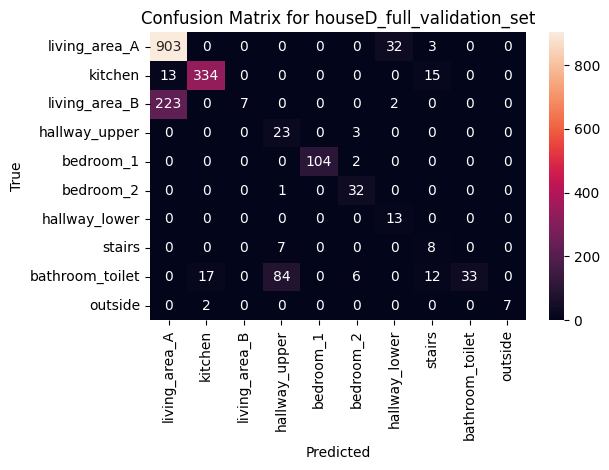


🎯 All experiments completed and results saved!


In [18]:
results = []

# Loop over experiments
for exp_name, split_ratio in labeled_experiments:

  labeled_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_labeled_{exp_name}.npz"
  unlabeled_npz = f"/content/drive/MyDrive/rssi_project/house_D_windowed_splits/houseD_full_validation_set.npz"

  # Prepare dataset
  loader_train, criterion = prepare_supervised_dataset(labeled_npz)

  # Sweep over hyperparameters
  for FEATURES_DISC in feature_disc_options:
    for LEARNING_RATE in learning_rate_options:

        print(f"➡️ FEATURES_DISC={FEATURES_DISC}, LEARNING_RATE={LEARNING_RATE}")
        model_name = f"SupervisedGAN_{exp_name}_FDISC{FEATURES_DISC}_LR{LEARNING_RATE}"

        # Load model
        gen, disc, opt_disc, scaler, scheduler_disc = load_pretrained_models(checkpoint_path)

        # Train model
        train_supervised_gan(
          gen,
          disc,
          loader_train,
          criterion,
          opt_disc,
          scheduler_disc
        )

        # Evaluate model
        acc, f1 = evaluate_supervised_gan(
          disc,
          unlabeled_npz,
          house_d_label_to_id,
          model_name
        )

        # Save result
        results.append({
          "experiment": exp_name,
          "split_ratio": split_ratio,
          "features_disc": FEATURES_DISC,
          "learning_rate": LEARNING_RATE,
          "accuracy": acc,
          "macro_f1": f1
        })

  # Save all results to CSV
  results_df = pd.DataFrame(results)
  results_df.to_csv("/content/drive/MyDrive/rssi_project/ssl_gan/supervised_gan_experiment_results.csv", index=False)

  print("\n🎯 All experiments completed and results saved!")
